Maximum displacement [m]: 0.00023934111688427386


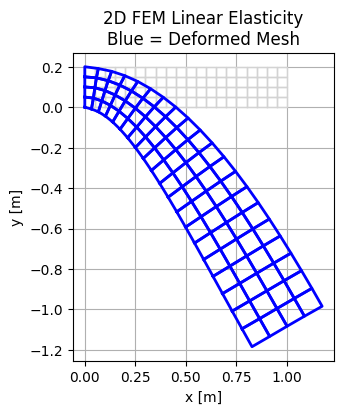

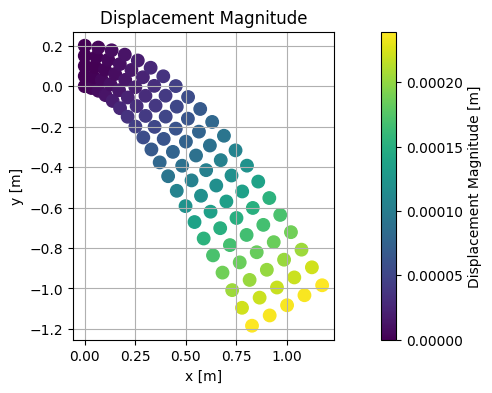

In [1]:
# ================================================================
# SIMPLE 2D FEM SIMULATION IN PYTHON
# Linear Elasticity on a Rectangular Plate using Finite Elements
# ================================================================
#
# This notebook demonstrates a very simple Finite Element Method
# (FEM) solver for 2D linear elasticity using:
#
# - Structured quadrilateral mesh
# - Bilinear Q4 elements
# - Plane stress formulation
# - Small deformation elasticity
# - Dense matrix assembly
#
# The left edge is fixed and a downward force is applied on the
# right edge.
#
# The code is intentionally educational and compact.
#
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# MATERIAL PROPERTIES
# ================================================================

E = 210e9          # Young's modulus [Pa]
nu = 0.3           # Poisson ratio
thickness = 0.01   # Plate thickness [m]

# Plane stress constitutive matrix
D = (E / (1 - nu**2)) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu)/2]
])

# ================================================================
# GEOMETRY
# ================================================================

Lx = 1.0   # Length [m]
Ly = 0.2   # Height [m]

nx = 20    # Elements in x
ny = 4     # Elements in y

# ================================================================
# MESH GENERATION
# ================================================================

x = np.linspace(0, Lx, nx + 1)
y = np.linspace(0, Ly, ny + 1)

nodes = []
for j in range(ny + 1):
    for i in range(nx + 1):
        nodes.append([x[i], y[j]])

nodes = np.array(nodes)
n_nodes = len(nodes)

# Element connectivity
elements = []

for j in range(ny):
    for i in range(nx):
        n1 = j * (nx + 1) + i
        n2 = n1 + 1
        n3 = n2 + (nx + 1)
        n4 = n1 + (nx + 1)

        elements.append([n1, n2, n3, n4])

elements = np.array(elements)
n_elements = len(elements)

# ================================================================
# FEM FUNCTIONS
# ================================================================

def shape_function_derivatives(xi, eta):
    dN_dxi = np.array([
        -(1 - eta),
         (1 - eta),
         (1 + eta),
        -(1 + eta)
    ]) * 0.25

    dN_deta = np.array([
        -(1 - xi),
        -(1 + xi),
         (1 + xi),
         (1 - xi)
    ]) * 0.25

    return dN_dxi, dN_deta


def element_stiffness(coords):

    # 2x2 Gauss quadrature
    gauss_points = [
        (-1/np.sqrt(3), -1/np.sqrt(3)),
        ( 1/np.sqrt(3), -1/np.sqrt(3)),
        ( 1/np.sqrt(3),  1/np.sqrt(3)),
        (-1/np.sqrt(3),  1/np.sqrt(3))
    ]

    ke = np.zeros((8, 8))

    for xi, eta in gauss_points:

        dN_dxi, dN_deta = shape_function_derivatives(xi, eta)

        # Jacobian
        J = np.zeros((2, 2))

        for i in range(4):
            J[0, 0] += dN_dxi[i] * coords[i, 0]
            J[0, 1] += dN_dxi[i] * coords[i, 1]
            J[1, 0] += dN_deta[i] * coords[i, 0]
            J[1, 1] += dN_deta[i] * coords[i, 1]

        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)

        # Shape function derivatives in physical coordinates
        dN = np.zeros((4, 2))

        for i in range(4):
            grad = invJ @ np.array([dN_dxi[i], dN_deta[i]])
            dN[i, 0] = grad[0]
            dN[i, 1] = grad[1]

        # Strain-displacement matrix
        B = np.zeros((3, 8))

        for i in range(4):
            B[0, 2*i]     = dN[i, 0]
            B[1, 2*i + 1] = dN[i, 1]
            B[2, 2*i]     = dN[i, 1]
            B[2, 2*i + 1] = dN[i, 0]

        ke += B.T @ D @ B * detJ * thickness

    return ke

# ================================================================
# GLOBAL MATRICES
# ================================================================

ndof = 2 * n_nodes

K = np.zeros((ndof, ndof))
F = np.zeros(ndof)

# ================================================================
# ASSEMBLY
# ================================================================

for el in elements:

    coords = nodes[el]

    ke = element_stiffness(coords)

    dofs = []

    for n in el:
        dofs.extend([2*n, 2*n + 1])

    for i in range(8):
        for j in range(8):
            K[dofs[i], dofs[j]] += ke[i, j]

# ================================================================
# BOUNDARY CONDITIONS
# ================================================================

# Fix left edge
fixed_dofs = []

for i, (xx, yy) in enumerate(nodes):
    if np.isclose(xx, 0.0):
        fixed_dofs.extend([2*i, 2*i + 1])

# Apply downward force on right edge
force = -1000.0  # N

right_nodes = []

for i, (xx, yy) in enumerate(nodes):
    if np.isclose(xx, Lx):
        right_nodes.append(i)

for n in right_nodes:
    F[2*n + 1] += force / len(right_nodes)

# ================================================================
# APPLY CONSTRAINTS
# ================================================================

free_dofs = np.setdiff1d(np.arange(ndof), fixed_dofs)

K_ff = K[np.ix_(free_dofs, free_dofs)]
F_f = F[free_dofs]

# ================================================================
# SOLVE SYSTEM
# ================================================================

U = np.zeros(ndof)

U_f = np.linalg.solve(K_ff, F_f)

U[free_dofs] = U_f

# ================================================================
# POSTPROCESSING
# ================================================================

ux = U[0::2]
uy = U[1::2]

magnitude = np.sqrt(ux**2 + uy**2)

print("Maximum displacement [m]:", np.max(magnitude))

# ================================================================
# VISUALIZATION
# ================================================================

scale = 5000

deformed_nodes = nodes.copy()

deformed_nodes[:, 0] += scale * ux
deformed_nodes[:, 1] += scale * uy

fig, ax = plt.subplots(figsize=(12, 4))

# Original mesh
for el in elements:
    pts = nodes[el]
    pts = np.vstack([pts, pts[0]])

    ax.plot(pts[:, 0], pts[:, 1],
            color='lightgray',
            linewidth=1)

# Deformed mesh
for el in elements:

    pts = deformed_nodes[el]
    pts = np.vstack([pts, pts[0]])

    ax.plot(pts[:, 0], pts[:, 1],
            color='blue',
            linewidth=2)

ax.set_aspect('equal')

ax.set_title("2D FEM Linear Elasticity\nBlue = Deformed Mesh")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.grid(True)
plt.show()

# ================================================================
# DISPLACEMENT FIELD
# ================================================================

fig, ax = plt.subplots(figsize=(12, 4))

sc = ax.scatter(
    deformed_nodes[:, 0],
    deformed_nodes[:, 1],
    c=magnitude,
    s=80
)

plt.colorbar(sc, label='Displacement Magnitude [m]')

ax.set_aspect('equal')

ax.set_title("Displacement Magnitude")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.grid(True)
plt.show()

# ================================================================
# END
# ================================================================